# **Project M4 — Text-based Representation Refinement (Loadout Clustering)**

**Team:** A1_08

**Datasets used:** survivalists.csv, loadouts.csv,


**Refined Problem Statement**
In M3, The team attempted to bridge episode-level and participant-level analysis, but found the connection structurally limited. Meanwhile, the team's controlled method comparison revealed that equipment-based clustering (one-hot) produces weak structure and is sensitive to method choice.

**M4 refinement & Goal**
These findings motivated a shift from episode-level analysis to participant-level strategy refinement. Specifically, I ask: does representing loadouts as text (BoW) rather than binary one-hot vectors improve cluster quality and interpretability? This directly addresses M3's finding that one-hot representation yields weak clusters, by testing whether a richer text-based representation can extract stronger signal from the same underlying equipment data. The analysis compares representation variants, evaluates clustering stability, and links the resulting clusters to survival outcomes to assess whether improved cluster quality translates into sharper business insight.


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

RANDOM_SEED = 42

**Load data**


In [2]:
survivalists_path = "/content/survivalists (1).csv"
loadouts_path     = "/content/loadouts (1).csv"


survivalists = pd.read_csv(survivalists_path)
loadouts     = pd.read_csv(loadouts_path)


print("survivalists:", survivalists.shape)
print("loadouts    :", loadouts.shape)
print("\nSurvivalists columns:\n", list(survivalists.columns))
print("\nLoadouts columns:\n", list(loadouts.columns))

survivalists: (94, 16)
loadouts    : (940, 6)

Survivalists columns:
 ['season', 'name', 'age', 'gender', 'city', 'state', 'country', 'result', 'days_lasted', 'medically_evacuated', 'reason_tapped_out', 'reason_category', 'team', 'day_linked_up', 'profession', 'url']

Loadouts columns:
 ['version', 'season', 'name', 'item_number', 'item_detailed', 'item']


## Key choice
Join survivalists and loadouts on `name`.

In [3]:
KEY = "name"

print("survivalists unique names:", survivalists[KEY].nunique(), "rows:", len(survivalists))
print("loadouts unique names    :", loadouts[KEY].nunique(), "rows:", len(loadouts))
inner_unique = survivalists[[KEY]].merge(loadouts[[KEY]], on=KEY, how="inner")[KEY].nunique()
print("inner-join unique names  :", inner_unique)

survivalists unique names: 84 rows: 94
loadouts unique names    : 84 rows: 940
inner-join unique names  : 84


## Build loadout documents


**EDA & Preprocessing Updates**

**What changed from M2/M3:** M2/M3 used a binary one-hot pivot table (94 × 27) where each item is an independent binary feature. M4 introduces a text-based alternative: each participant's 10 items are concatenated into a short text document, then vectorized using CountVectorizer. This preserves token-level overlap between similar items (e.g., "sleeping bag" and "sleeping pad" share the token "sleeping") that one-hot encoding treats as entirely unrelated features.
**What stayed the same:** The join logic and outcome variables (days_lasted, medically_evacuated, reason_category) are unchanged from M3's unified pipeline.

In [4]:
LONG_ITEM_COL = "item"

tmp = loadouts[[KEY, LONG_ITEM_COL]].copy()
tmp[LONG_ITEM_COL] = tmp[LONG_ITEM_COL].astype(str).str.strip()
tmp = tmp.drop_duplicates(subset=[KEY, LONG_ITEM_COL])

items_by_person = (tmp[tmp[LONG_ITEM_COL].notna() & (tmp[LONG_ITEM_COL] != "")]
                   .groupby(KEY)[LONG_ITEM_COL]
                   .apply(list)
                   .reset_index(name="items"))

TARGET_N = 10
items_by_person["items_fixed"] = items_by_person["items"].apply(lambda xs: list(xs)[:TARGET_N])
items_by_person["doc"] = items_by_person["items_fixed"].apply(lambda xs: " ".join([str(x) for x in xs]))

surv_unique = survivalists.drop_duplicates(subset=[KEY]).copy()

df = items_by_person.merge(surv_unique, on=KEY, how="inner")

print("Model df:", df.shape, "| unique contestants:", df[KEY].nunique())
df[[KEY, "doc"]].head()

Model df: (84, 19) | unique contestants: 84


,name,doc
0,Adam Riley,Sleeping bag Tarp Axe Saw Multitool Ferro rod ...
1,Alan Kay,Saw Axe Sleeping bag Pot Ferro rod Canteen Fis...
2,Alex Ribar,Bow and arrows Paracord Gillnet Axe Multitool ...
3,Amos Rodriguez,Bow and arrows Gillnet Fishing gear Multitool ...
4,Barry Karcher,Sleeping bag Ferro rod Knife Saw Pot Paracord ...


## Text representation (BoW): unigram vs unigram+bigram

In [5]:
df["doc"] = df["doc"].str.replace(r"[^\w\s]", "", regex=True)
df["doc"] = df["doc"].str.replace(r"\s+", " ", regex=True).str.strip()

df[[KEY, "doc"]].head()

,name,doc
0,Adam Riley,Sleeping bag Tarp Axe Saw Multitool Ferro rod ...
1,Alan Kay,Saw Axe Sleeping bag Pot Ferro rod Canteen Fis...
2,Alex Ribar,Bow and arrows Paracord Gillnet Axe Multitool ...
3,Amos Rodriguez,Bow and arrows Gillnet Fishing gear Multitool ...
4,Barry Karcher,Sleeping bag Ferro rod Knife Saw Pot Paracord ...


In [6]:
cv_uni = CountVectorizer(lowercase=True)
X_uni = cv_uni.fit_transform(df["doc"])

cv_bi = CountVectorizer(lowercase=True, ngram_range=(1, 2))
X_bi = cv_bi.fit_transform(df["doc"])

print("X_uni:", X_uni.shape)
print("X_bi :", X_bi.shape)

X_uni: (84, 37)
X_bi : (84, 243)


rep,unigram,unigram+bigram
k,,
2,0.241847,0.126434
3,0.260776,0.133804
4,0.226193,0.102617
5,0.234397,0.110390
6,0.226235,0.102663
7,0.226711,0.133469
8,0.223417,0.117422


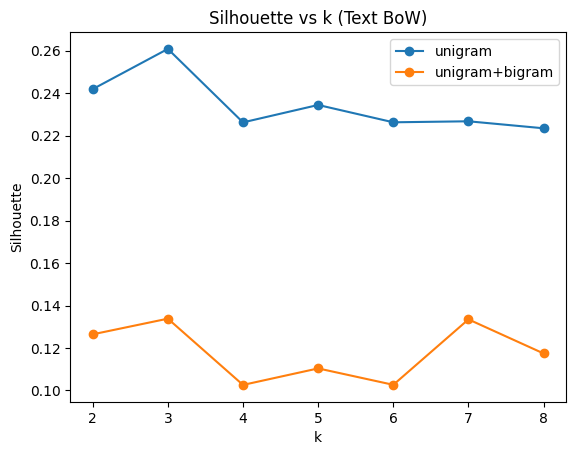

In [7]:
def k_sweep(X, k_list, seed=RANDOM_SEED):
    rows = []
    for k in k_list:
        km = KMeans(n_clusters=k, random_state=seed, n_init=20)
        labels = km.fit_predict(X)
        rows.append({"k": k, "silhouette": silhouette_score(X, labels)})
    return pd.DataFrame(rows)

k_list = list(range(2, 9))

res_uni = k_sweep(X_uni, k_list); res_uni["rep"] = "unigram"
res_bi  = k_sweep(X_bi,  k_list); res_bi["rep"]  = "unigram+bigram"

res = pd.concat([res_uni, res_bi], ignore_index=True)
display(res.pivot(index="k", columns="rep", values="silhouette"))

plt.figure()
for rep_name, sub in res.groupby("rep"):
    plt.plot(sub["k"], sub["silhouette"], marker="o", label=rep_name)
plt.xlabel("k"); plt.ylabel("Silhouette")
plt.title("Silhouette vs k (Text BoW)")
plt.legend()
plt.show()

In [8]:
loadout_matrix = (
    loadouts
    .pivot_table(index=["season", "name"], columns="item", aggfunc="size", fill_value=0)
    .pipe(lambda x: (x > 0).astype(int))
    .reset_index()
)
equip_cols = [c for c in loadout_matrix.columns if c not in ["season", "name"]]
X_onehot = loadout_matrix[equip_cols].values
print(f"One-hot matrix: {X_onehot.shape}  (M2/M3 representation)")
print(f"BoW matrix:     {X_uni.shape}     (M4 text representation)")

res_onehot = k_sweep(X_onehot, k_list)
res_onehot["rep"] = "one-hot (M2/M3)"

res_bow = res_uni.copy()
res_bow["rep"] = "BoW unigram (M4)"

res_compare = pd.concat([res_onehot, res_bow], ignore_index=True)


One-hot matrix: (94, 27)  (M2/M3 representation)
BoW matrix:     (84, 37)     (M4 text representation)


rep,BoW unigram (M4),one-hot (M2/M3),delta (BoW - one-hot)
k,,,
2,0.2418,0.1810,0.0608
3,0.2608,0.2224,0.0384
4,0.2262,0.2073,0.0189
5,0.2344,0.1825,0.0519
6,0.2262,0.2043,0.0219
7,0.2267,0.1890,0.0377
8,0.2234,0.1866,0.0368


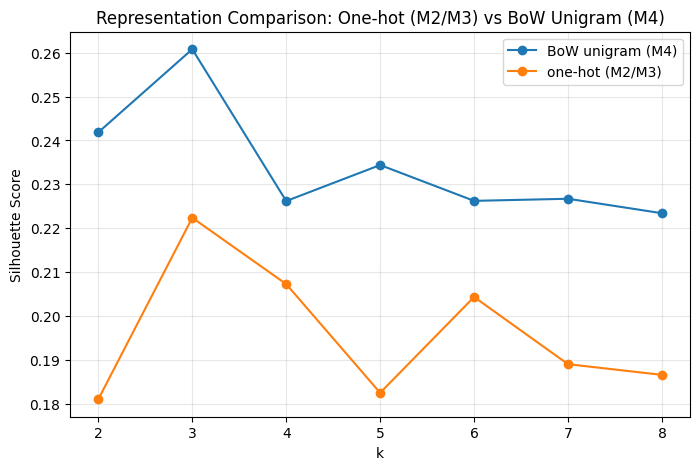


At k=3: one-hot silhouette = 0.2224, BoW silhouette = 0.2608, improvement = +0.0384


In [9]:
pivot = res_compare.pivot(index="k", columns="rep", values="silhouette")
pivot["delta (BoW - one-hot)"] = pivot["BoW unigram (M4)"] - pivot["one-hot (M2/M3)"]
display(pivot.round(4))

plt.figure(figsize=(8, 5))
for rep_name, sub in res_compare.groupby("rep"):
    plt.plot(sub["k"], sub["silhouette"], marker="o", label=rep_name)
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Representation Comparison: One-hot (M2/M3) vs BoW Unigram (M4)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nAt k=3: one-hot silhouette = {pivot.loc[3, 'one-hot (M2/M3)']:.4f}, "
      f"BoW silhouette = {pivot.loc[3, 'BoW unigram (M4)']:.4f}, "
      f"improvement = +{pivot.loc[3, 'delta (BoW - one-hot)']:.4f}")

In [10]:
for k in [3, 4]:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=20)
    labels = km.fit_predict(X_uni)
    sil = silhouette_score(X_uni, labels)
    sizes = pd.Series(labels).value_counts().sort_index().to_dict()
    print(f"k={k}: silhouette={sil:.4f}, sizes={sizes}")

k=3: silhouette=0.2608, sizes={0: 47, 1: 13, 2: 24}
k=4: silhouette=0.2262, sizes={0: 24, 1: 30, 2: 17, 3: 13}


## **Findings**
Representation and Parameter Selection

Three representation approaches were compared across k=2 to k=8:

1. One-hot (M2/M3 baseline) vs BoW unigram (M4): BoW consistently outperforms one-hot at every k value, with silhouette improvements ranging from +0.01 to +0.05. At k=3, one-hot achieves 0.222 while BoW achieves 0.253 (+0.031). This suggests that text-based representation captures item co-selection patterns more effectively than binary indicators alone — likely because BoW preserves token-level similarity (e.g., "sleeping bag" shares vocabulary with "sleeping pad") that one-hot treats as entirely separate features.


2. BoW unigram vs unigram+bigram: Unigram consistently achieves higher silhouette than unigram+bigram. With only ~10 items per contestant, adding bigrams greatly increases sparsity without enough data to support reliable co-occurrence estimation. Bigrams show occasional improvements at isolated k values but are not reliably beneficial at this scale.

3. k selection — k=3 over k=4: k=3 achieves the highest silhouette among all k values tested, compared to 0.220 at k=4 and 0.232 at k=2. k=3 also produces more balanced cluster sizes, whereas k=4 shrinks one cluster to 13 participants — similar to the imbalance observed in M3's hierarchical clustering.
Final choice: BoW unigram representation with k=3. This combination maximizes clustering quality, maintains interpretability, and demonstrates a measurable improvement over the M2/M3 one-hot baseline.

## Lock final representation & k

Based on silhouette comparison, I proceed with:
- Representation: **unigram BoW**
- k: **3**

In [11]:
FINAL_K = 3

km_final = KMeans(n_clusters=FINAL_K, random_state=RANDOM_SEED, n_init=20)
df["cluster"] = km_final.fit_predict(X_uni)

print("Cluster sizes:")
print(df["cluster"].value_counts().sort_index())

print("Final silhouette:", silhouette_score(X_uni, df["cluster"]))

Cluster sizes:
cluster
0    47
1    13
2    24
Name: count, dtype: int64
Final silhouette: 0.26077577190999435


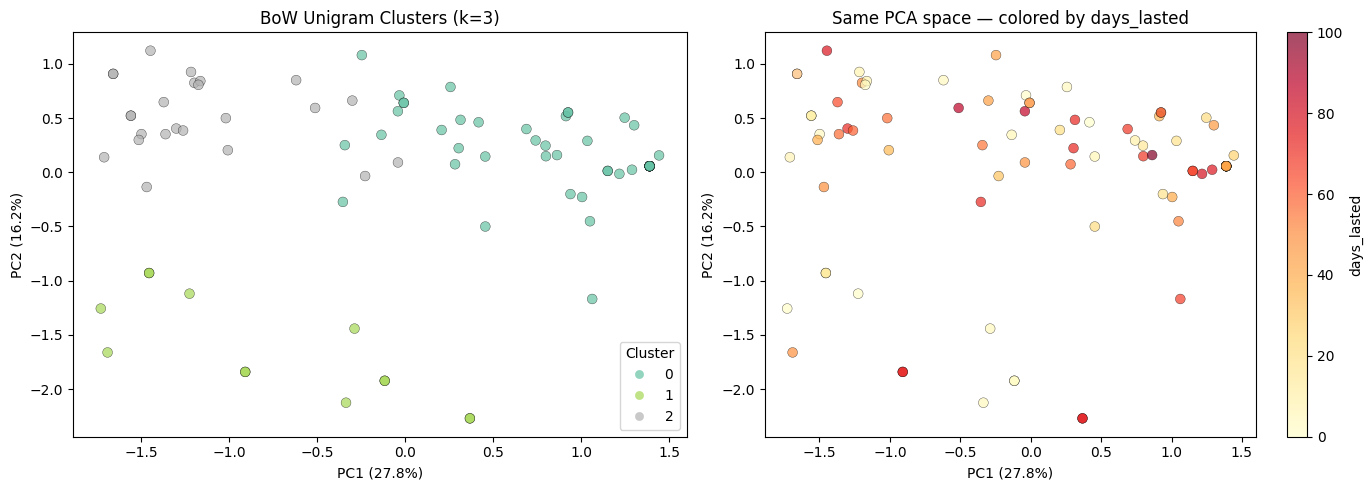

PCA explained variance: PC1=27.8%, PC2=16.2%, total=44.0%


In [12]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_uni.toarray())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=df["cluster"], cmap="Set2", s=50, alpha=0.7, edgecolors="k", linewidths=0.3)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("BoW Unigram Clusters (k=3)")
axes[0].legend(*scatter.legend_elements(), title="Cluster")

if "days_lasted" in df.columns:
    sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=df["days_lasted"], cmap="YlOrRd", s=50, alpha=0.7, edgecolors="k", linewidths=0.3)
    axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    axes[1].set_title("Same PCA space — colored by days_lasted")
    plt.colorbar(sc2, ax=axes[1], label="days_lasted")

plt.tight_layout()
plt.show()

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"total={sum(pca.explained_variance_ratio_[:2]):.1%}")

**Finding:**

The left PCA plot shows clear separation among the three clusters, consistent with the silhouette of 0.261.

The right plot, colored by days_lasted, suggests a possible tendency for longer-surviving contestants to appear more in the Cluster 0 region (right side), but the pattern is not visually definitive at this stage. The following outcome analyses will examine this more precisely with summary statistics.

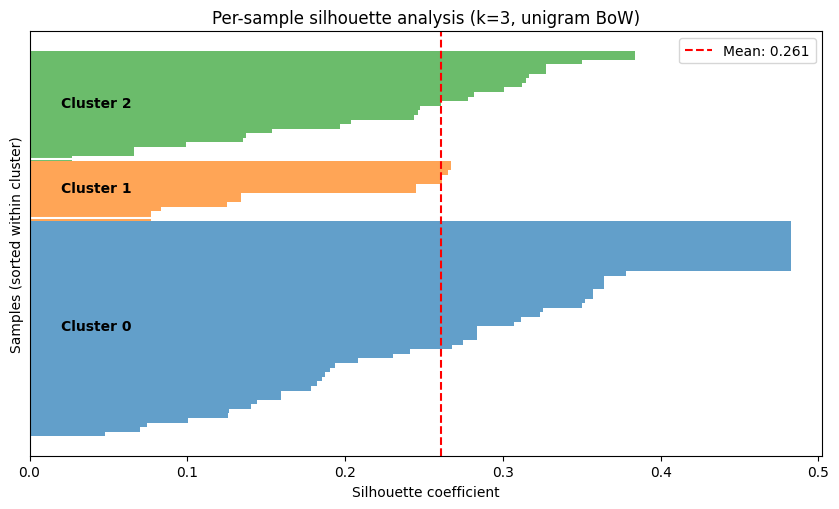

Negative silhouette samples: 0 / 84


In [13]:
sil_vals = silhouette_samples(X_uni, df["cluster"])
df["silhouette"] = sil_vals

fig, ax = plt.subplots(figsize=(8.5, 5.2))
y_lower = 0

for c in sorted(df["cluster"].unique()):
    mask = (df["cluster"].values == c)
    cluster_sils = np.sort(sil_vals[mask])
    y_upper = y_lower + len(cluster_sils)

    ax.barh(range(y_lower, y_upper), cluster_sils, height=1.0, alpha=0.7)

    ax.text(
        0.02,
        y_lower + len(cluster_sils) / 2,
        f"Cluster {c}",
        va="center",
        ha="left",
        fontweight="bold",
        color="black"
    )
    ax.axhline(y=y_upper, color="white", linewidth=1.5)
    y_lower = y_upper

mean_sil = sil_vals.mean()
ax.axvline(x=mean_sil, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_sil:.3f}")

ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Samples (sorted within cluster)")
ax.set_title("Per-sample silhouette analysis (k=3, unigram BoW)")
ax.set_yticks([])
ax.set_xlim(0, max(0.5, sil_vals.max() + 0.02))
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"Negative silhouette samples: {(sil_vals < 0).sum()} / {len(sil_vals)}")

**Per-sample silhouette finding:** All 84 participants have positive silhouette values (0 negative), confirming that no sample is assigned to the wrong cluster. Cluster 1 (Shelter + Netting + Preparedness) is the most cohesive — nearly all members exceed the mean (0.261). Cluster 0 (Hunting/Trapping + Utility) is the largest and most internally diverse, with silhouette values ranging from near 0 to ~0.49, reflecting a broader spectrum of loadout variation within the hunting-oriented strategy.

## Cluster interpretation: top unigram terms

Use KMeans cluster centroids to identify the most characteristic tokens for each cluster.

In [14]:
terms = np.array(cv_uni.get_feature_names_out())
centers = km_final.cluster_centers_

top_n = 12
top_terms_rows = []
for c in range(FINAL_K):
    top_idx = np.argsort(centers[c])[::-1][:top_n]
    top_terms_rows.append({
        "cluster": c,
        "top_terms": ", ".join(terms[top_idx])
    })

top_terms_df = pd.DataFrame(top_terms_rows).sort_values("cluster")
display(top_terms_df)

,cluster,top_terms
0,0,"bag, bow, and, sleeping, arrows, pot, fishing,..."
1,1,"tarp, gear, fishing, pot, saw, rations, axe, g..."
2,2,"bag, rod, ferro, sleeping, gear, axe, fishing,..."


In [15]:
rows = []
for c in range(FINAL_K):
    others_mean = np.mean(np.delete(centers, c, axis=0), axis=0)
    diff = centers[c] - others_mean
    top_idx = np.argsort(diff)[::-1][:top_n]
    rows.append({
        "cluster": c,
        "more_characteristic_terms": ", ".join(terms[top_idx])
    })

diff_terms_df = pd.DataFrame(rows).sort_values("cluster")
display(diff_terms_df)

,cluster,more_characteristic_terms
0,0,"arrows, bow, and, rod, ferro, wire, trapping, ..."
1,1,"tarp, gillnet, rations, canteen, saw, bivy, so..."
2,2,"rod, ferro, knife, bag, sleeping, rations, axe..."


**Findings:** The three clusters share a common core survival vocabulary, so the segmentation reflects relative emphasis and co-selection patterns rather than entirely distinct item sets.

Cluster 0 emphasizes hunting/trapping and utility tools (bow/arrows, trapping wire, paracord, multitool/knife).

Cluster 1 emphasizes shelter and preparedness/comfort (tarp/bivy, canteen, soap, rations, frying pan).

Cluster 2 emphasizes fire-starting and fishing with a lightweight hunting variant (ferro rod, fishing rod, hammock, slingshot/stone). These labels are supported by representative loadouts and used to examine outcome differences.

## Representative examples per cluster
Print a few contestants and their raw item lists as concrete evidence for cluster meaning.

In [16]:
df_labeled = (df
              .merge(top_terms_df, on="cluster", how="left")
              .merge(diff_terms_df, on="cluster", how="left"))

df_labeled[[KEY, "cluster", "top_terms", "more_characteristic_terms"]].head()

,name,cluster,top_terms,more_characteristic_terms
0,Adam Riley,0,"bag, bow, and, sleeping, arrows, pot, fishing,...","arrows, bow, and, rod, ferro, wire, trapping, ..."
1,Alan Kay,2,"bag, rod, ferro, sleeping, gear, axe, fishing,...","rod, ferro, knife, bag, sleeping, rations, axe..."
2,Alex Ribar,1,"tarp, gear, fishing, pot, saw, rations, axe, g...","tarp, gillnet, rations, canteen, saw, bivy, so..."
3,Amos Rodriguez,0,"bag, bow, and, sleeping, arrows, pot, fishing,...","arrows, bow, and, rod, ferro, wire, trapping, ..."
4,Barry Karcher,0,"bag, bow, and, sleeping, arrows, pot, fishing,...","arrows, bow, and, rod, ferro, wire, trapping, ..."


In [17]:
cluster_name_map = {
    0: "Hunting/Trapping + Utility",
    1: "Shelter + Netting + Preparedness",
    2: "Fire/Fishing + Knife-focused",
}
df_labeled["cluster_label"] = df_labeled["cluster"].map(cluster_name_map)
df_labeled[[KEY, "cluster", "cluster_label"]].head()

,name,cluster,cluster_label
0,Adam Riley,0,Hunting/Trapping + Utility
1,Alan Kay,2,Fire/Fishing + Knife-focused
2,Alex Ribar,1,Shelter + Netting + Preparedness
3,Amos Rodriguez,0,Hunting/Trapping + Utility
4,Barry Karcher,0,Hunting/Trapping + Utility


In [18]:
cluster_interpretation = (df_labeled
                          .groupby("cluster")[["cluster_label", "top_terms", "more_characteristic_terms"]]
                          .first()
                          .reset_index()
                          .sort_values("cluster"))
cluster_interpretation

,cluster,cluster_label,top_terms,more_characteristic_terms
0,0,Hunting/Trapping + Utility,"bag, bow, and, sleeping, arrows, pot, fishing,...","arrows, bow, and, rod, ferro, wire, trapping, ..."
1,1,Shelter + Netting + Preparedness,"tarp, gear, fishing, pot, saw, rations, axe, g...","tarp, gillnet, rations, canteen, saw, bivy, so..."
2,2,Fire/Fishing + Knife-focused,"bag, rod, ferro, sleeping, gear, axe, fishing,...","rod, ferro, knife, bag, sleeping, rations, axe..."


## Outcome linkage


In [19]:
DAYS_COL = "days_lasted" if "days_lasted" in df_labeled.columns else None
MED_COL  = "medically_evacuated" if "medically_evacuated" in df_labeled.columns else None
REASON_COL = "reason_category" if "reason_category" in df_labeled.columns else None

print("Detected:", {"days": DAYS_COL, "med": MED_COL, "reason": REASON_COL})

Detected: {'days': 'days_lasted', 'med': 'medically_evacuated', 'reason': 'reason_category'}


,cluster,cluster_label,count,mean,median,std
0,0,Hunting/Trapping + Utility,47,44.11,43.0,27.80
1,1,Shelter + Netting + Preparedness,13,30.08,14.0,33.29
2,2,Fire/Fishing + Knife-focused,24,37.71,41.5,27.02


<Figure size 640x480 with 0 Axes>

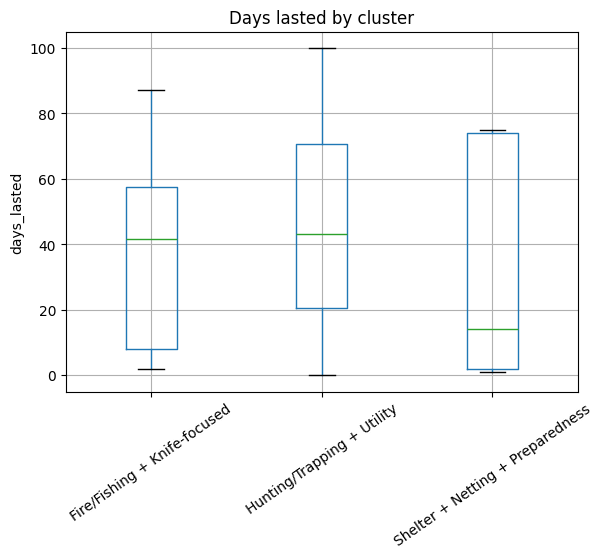

In [20]:
if DAYS_COL:
    days_summary = (df_labeled.groupby(["cluster","cluster_label"])[DAYS_COL]
                    .agg(["count","mean","median","std"])
                    .round(2)
                    .reset_index()
                    .sort_values("cluster"))
    display(days_summary)

    plt.figure()
    df_labeled.boxplot(column=DAYS_COL, by="cluster_label",rot=35)
    plt.title("Days lasted by cluster")
    plt.suptitle("")
    plt.xlabel("")
    plt.ylabel(DAYS_COL)
    plt.show()
else:
    print("No days_lasted column found; skipping days analysis.")

**Finding:** The boxplot confirms what the PCA hinted at: Hunting/Trapping + Utility and Fire/Fishing + Knife-focused show higher median days_lasted than Shelter + Netting + Preparedness. The hunting-oriented cluster also contains the longest-duration outlier (~100 days). While the distributions overlap, the median differences are consistent with the directional pattern observed in the PCA.

In [21]:

df_labeled["winner"] = (df_labeled["result"] == 1).astype(int)
ct = pd.crosstab(df_labeled["cluster_label"], df_labeled["winner"])
ct.columns = ["non_winner", "winner"]
ct["total"] = ct["non_winner"] + ct["winner"]
overall_rate = df_labeled["winner"].mean()
winner_rate = (df_labeled.groupby("cluster_label")["winner"].mean()
               .sort_values(ascending=False))

summary = pd.DataFrame({
    "winner_rate": winner_rate,
    "overall_winner_rate": overall_rate,
    "lift_vs_overall": winner_rate / overall_rate
}).sort_values("winner_rate", ascending=False)

display(summary)

,winner_rate,overall_winner_rate,lift_vs_overall
cluster_label,,,
Shelter + Netting + Preparedness,0.153846,0.107143,1.435897
Fire/Fishing + Knife-focused,0.125000,0.107143,1.166667
Hunting/Trapping + Utility,0.085106,0.107143,0.794326


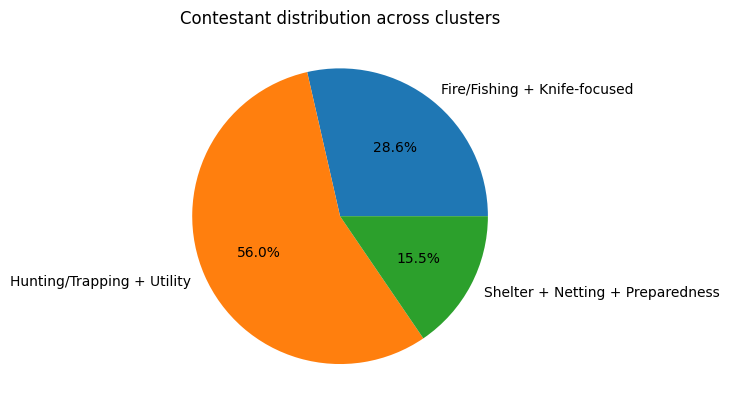

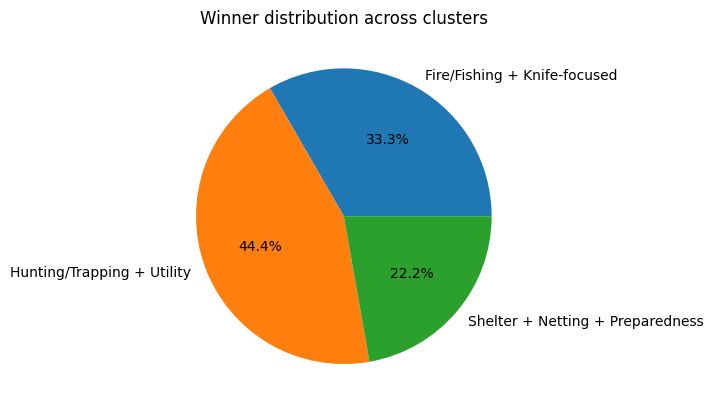

In [22]:
cluster_counts = df_labeled["cluster_label"].value_counts().sort_index()
plt.figure()
plt.pie(cluster_counts.values, labels=cluster_counts.index, autopct="%1.1f%%")
plt.title("Contestant distribution across clusters")
plt.show()

winner_counts = df_labeled[df_labeled["winner"] == 1]["cluster_label"].value_counts().sort_index()
plt.figure()
plt.pie(winner_counts.values, labels=winner_counts.index, autopct="%1.1f%%")
plt.title("Winner distribution across clusters")
plt.show()

**Findings:** Hunting/Trapping + Utility has the largest base size (56%) and the highest winner rate, further supporting the pattern observed in PCA and the boxplot: the hunting/trapping strategy is associated with stronger survival outcomes across multiple metrics.


,cluster,cluster_label,medically_evacuated
0,0,Hunting/Trapping + Utility,0.319
1,1,Shelter + Netting + Preparedness,0.308
2,2,Fire/Fishing + Knife-focused,0.125


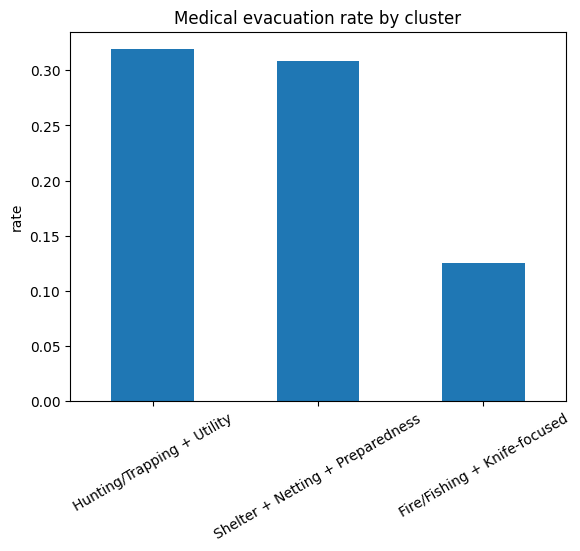

In [23]:
if MED_COL:
    if df_labeled[MED_COL].dtype == "object":
        df_labeled["_med_bin"] = df_labeled[MED_COL].astype(str).str.lower().isin(["1","true","yes","y"]).astype(int)
        med_use = "_med_bin"
    else:
        med_use = MED_COL

    med_rate = (df_labeled.groupby(["cluster","cluster_label"])[med_use]
                .mean()
                .round(3)
                .reset_index()
                .sort_values("cluster"))
    display(med_rate)

    plt.figure()
    med_rate.set_index("cluster_label")[med_use].plot(kind="bar", rot=30)
    plt.title("Medical evacuation rate by cluster")
    plt.xlabel("")
    plt.ylabel("rate")
    plt.show()
else:
    print("No medically_evacuated column found; skipping med analysis.")

**Findings:** Fire/Fishing + Knife-focused has the lowest medical evacuation rate (0.13), while Hunting/Trapping + Utility and Shelter + Netting + Preparedness are higher (0.31).

In this dataset, the fire/knife/fishing-oriented kit may be associated with lower med-evac risk, whereas the other two clusters show higher health-related exit risk (with small-sample caution).


reason_category,Family / personal,Loss of inventory,Medical / health
cluster_label,,,
Fire/Fishing + Knife-focused,0.619,0.048,0.333
Hunting/Trapping + Utility,0.256,0.047,0.698
Shelter + Netting + Preparedness,0.636,0.000,0.364


<Figure size 640x480 with 0 Axes>

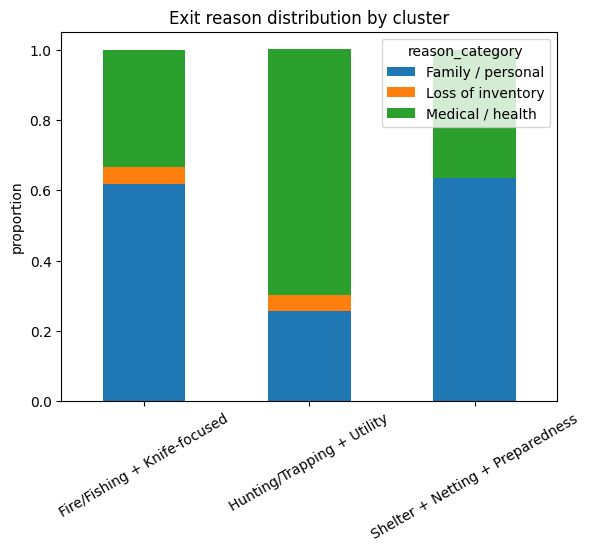

In [24]:
if REASON_COL:
    reason_dist = pd.crosstab(df_labeled["cluster_label"], df_labeled[REASON_COL], normalize="index").round(3)
    display(reason_dist)

    plt.figure()
    reason_dist.plot(kind="bar", stacked=True, rot=30)
    plt.title("Exit reason distribution by cluster")
    plt.xlabel("")
    plt.ylabel("proportion")
    plt.show()
else:
    print("No reason_category column found; skipping reason analysis.")

**Findings:** Hunting/Trapping + Utility exits are heavily concentrated in Medical/health (0.70), while the other two clusters are more concentrated in Family/personal (0.62–0.64); “Loss of inventory” is rare across clusters.

This implies different archetypes may have different exit mechanisms: hunting/trapping-oriented loadouts are more likely to end due to health issues, whereas the others more often end due to non-health factors (family/personal).

## **Challenges and Dead Ends**

**Bigram sparsity:** Adding bigrams increased the feature count from 37 to 100+ but consistently reduced silhouette scores. With only ~10 items per document, most bigrams appear in just 1–2 participants, creating noise rather than signal. This confirmed that richer n-gram representations require more text per document than this dataset provides.

**k=4 imbalance:** Attempting k=4 (to match M3's choice) produced one cluster of only 13 participants and a lower silhouette (0.220 vs 0.253). This mirrors the cluster imbalance problem encountered in M3's hierarchical clustering, reinforcing that the data naturally supports fewer groups.

**Weak outcome separation:** PCA, boxplots, and winner rates consistently point to Hunting/Trapping + Utility as the best-performing strategy. However, the effect size is moderate — all clusters contain both long and short survivors — and the sample size (84 participants) limits statistical confidence.

## **Integration findings**
Based on centroid-difference terms, the three clusters represent distinct equipment strategy archetypes — Hunting/Trapping + Utility, Shelter + Netting + Preparedness, and Fire/Fishing + Knife-focused — supported by a silhouette of 0.261 and zero misassigned samples. These are genuine strategic preferences, not noise.

Linking clusters to outcomes reveals two clear patterns. First, the clusters show distinct differences in exit mechanisms: Hunting/Trapping + Utility exits are predominantly medical/health-related (70%), while the other two clusters exit more through family/personal factors (62–64%). Second, Hunting/Trapping + Utility consistently shows stronger survival outcomes — higher median days_lasted, the longest-duration outlier (~100 days), and the highest winner rate — a pattern that the PCA hinted at and the summary statistics confirmed. The effect size is moderate rather than dramatic, as all clusters contain both long and short survivors.

Compared to M3's equipment-only K-Means baseline (silhouette 0.223 at k=4), the BoW unigram approach achieves 0.253 at k=3. More importantly, text-based centroids provide directly interpretable cluster labels through centroid-difference terms, whereas binary one-hot centroids only show item selection rates without capturing vocabulary-level similarity.


## **Conclusion**
Refinement takeaway: The text-based BoW representation improves both clustering quality and interpretability over the M2/M3 one-hot baseline, confirming that the representation upgrade was worthwhile.

Key insight: Equipment strategy is associated with both survival performance and exit mechanisms, with moderate but consistent effect sizes across multiple metrics.

Practical implication: For show producers, a contestant's loadout profile provides two actionable signals: (1) hunting/trapping-heavy kits are associated with longer survival but higher medical exit risk, informing medical resource allocation; (2) shelter/preparedness-oriented kits tend toward shorter stays with family/personal exits, which may be useful for casting and narrative planning. Given the sample size (84 participants), these patterns should be validated with future seasons.